In [1]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from pathlib import Path
import numpy as np
import re
import pandas as pd

### Preprocessing from previous Task:

In [2]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

with open(
    "FinancialPhraseBank/FinancialPhraseBank-v1.0/Sentences_50Agree.txt",
    encoding="latin-1"
) as sentences_file:
    raw_sentences = sentences_file.read()

sentences_list_with_sentiments = raw_sentences.split("\n")[:-1]

sentences_list = []
y = []
sentiment_dictionary = {"negative": 2, "neutral": 0, "positive": 1}

for sentence in sentences_list_with_sentiments:
    text, sentiment = sentence.rsplit('@', 1)
    sentences_list.append(text)
    y.append(sentiment_dictionary[sentiment])
y = np.array(y)

def preprocess_sentences(sentences_list):
    sentences_list_all_lower = [sentence.lower() for sentence in sentences_list]

    noise_characters_dict = {"%": "", ",":"", "(":"", ")":"", ":":"", "n't":" not", "'s":"", "€":"", "$":"", "``":"", "''":"", "...":"", "`":"", "'":"" ,"  ":" "}
    sentences_list_denoised = sentences_list_all_lower
    for noise_character, replace_character in noise_characters_dict.items():
        sentences_list_denoised = [sentence.replace(noise_character, replace_character) for sentence in sentences_list_denoised]

    nltk_stop_words = set(stopwords.words('english'))
    not_stop_words = {"above", "after", "against", "before", "below", "between", "down", "from", "no", "not", "nor", "off", "only", "over", "same", "to", "under", "up"}
    additional_stop_words = {"bln", "mln", "pct", "percent"}
    stop_words = (nltk_stop_words - not_stop_words).union(additional_stop_words)
    sentences_list_without_stop_words = []
    for sentence in sentences_list_denoised:
        words_list = word_tokenize(sentence)
        sentence_without_stop_words = " ".join([word for word in words_list if word not in stop_words])
        sentences_list_without_stop_words.append(sentence_without_stop_words)
    
    lemmatizer = WordNetLemmatizer()
    sentences_list_lemmatized = []
    for sentence in sentences_list_without_stop_words:
        words_list = word_tokenize(sentence)
        sentence_lemmatized = " ".join([lemmatizer.lemmatize(word) for word in words_list])
        sentences_list_lemmatized.append(sentence_lemmatized)

    sentences_list_only_ascii = sentences_list_lemmatized
    sentences_list_only_ascii = [re.sub(r'[^.a-zA-Z0-9\s<>\-]', '', sentence) for sentence in sentences_list_only_ascii]

    sentences_list_without_numbers = []
    for sentence in sentences_list_only_ascii:
        sentence_without_numbers = re.sub(r'\b\d+\s*(?:[\.,]\s*\d+)?\b', ' <NUM> ', sentence).replace(".", "").replace("-", " ").replace("  ", " ")
        sentences_list_without_numbers.append(sentence_without_numbers)
    
    return sentences_list_all_lower, sentences_list_denoised, sentences_list_without_stop_words, sentences_list_lemmatized, sentences_list_only_ascii, sentences_list_without_numbers

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/theohagen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/theohagen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/theohagen/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/theohagen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
_, _, _, _, _, X = preprocess_sentences(sentences_list)


### Some more conditionals:

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.utils import resample
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

### Creating Train/Test Split:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    train_size=0.8, 
    random_state=43, # repeatability
    shuffle=True, # ensure randomness
    stratify=y # ensure same class dist. between train and test
)

### Naive Bayes with BoW:

In [6]:
def naive_Bayes_BoW(X_train, y_train):
    """
    Train Naive Bayes model with Bag of Words representation.

    Parameters:
        X_train: Training texts
        y_train: Training labels

    Returns Fitted sklearn Pipeline
    """
    model = Pipeline([
        ("vectorizer", CountVectorizer()),
        ("classifier", MultinomialNB())
    ])

    model.fit(X_train, y_train)
    
    return model

model = naive_Bayes_BoW(X_train, y_train)
pred_bog = model.predict(X_test)

print(f"Report:\n{classification_report(y_test, pred_bog)}")

Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       576
           1       0.63      0.55      0.59       273
           2       0.61      0.50      0.55       121

    accuracy                           0.73       970
   macro avg       0.68      0.64      0.65       970
weighted avg       0.72      0.73      0.72       970



### Naive Bayes with Tfidf:

In [7]:
def naive_Bayes_Tfidf(X_train, y_train):
    """
    Train Naive Bayes model with Tfidf representation.

    Parameters:
        X_train: Training texts
        y_train: Training labels

    Returns Fitted sklearn Pipeline
    """
    model = Pipeline([
        ("vectorizer", TfidfVectorizer()),
        ("classifier", MultinomialNB())
    ])

    model.fit(X_train, y_train)

    return model

model = naive_Bayes_Tfidf(X_train, y_train)
pred_tfidf = model.predict(X_test)

print(f"Report:\n{classification_report(y_test, pred_tfidf)}")

Report:
              precision    recall  f1-score   support

           0       0.69      0.98      0.81       576
           1       0.68      0.35      0.46       273
           2       1.00      0.06      0.11       121

    accuracy                           0.69       970
   macro avg       0.79      0.46      0.46       970
weighted avg       0.72      0.69      0.62       970



In [8]:
pred = pd.DataFrame({
    "BoG": pred_bog,
    "Tfidf": pred_tfidf
})
print(pred.apply(pd.Series.value_counts, normalize=True).round(3))

     BoG  Tfidf
0  0.652  0.847
1  0.247  0.145
2  0.101  0.007


In [9]:
df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})
df["label"].value_counts()

label
0    2303
1    1090
2     483
Name: count, dtype: int64

### Oversampling

In [10]:
max_class_size = df["label"].value_counts().max()
oversampled = []

for label in df["label"].unique():

    class_df = df[df["label"] == label]

    label_oversample = resample(
        class_df,
        replace=True,
        n_samples=max_class_size,
        random_state=43
    )
    oversampled.append(label_oversample)


df_oversampled = pd.concat(oversampled)
df_oversampled["label"].value_counts()

label
1    2303
0    2303
2    2303
Name: count, dtype: int64

### Naive Bayes, BoW, Oversampled

In [11]:
model = naive_Bayes_BoW(df_oversampled["text"], df_oversampled["label"])
y_pred_oversampled = model.predict(X_test)
print(f"Report:\n{classification_report(y_test, y_pred_oversampled)}")

Report:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77       576
           1       0.52      0.48      0.50       273
           2       0.40      0.74      0.52       121

    accuracy                           0.65       970
   macro avg       0.58      0.64      0.59       970
weighted avg       0.69      0.65      0.66       970



### Naive Bayes, Tfidf, Oversampled

In [12]:
model = naive_Bayes_Tfidf(df_oversampled["text"], df_oversampled["label"])
y_pred_oversampled = model.predict(X_test)
print(f"Report:\n{classification_report(y_test, y_pred_oversampled)}")

Report:
              precision    recall  f1-score   support

           0       0.85      0.70      0.77       576
           1       0.53      0.53      0.53       273
           2       0.41      0.74      0.52       121

    accuracy                           0.66       970
   macro avg       0.59      0.66      0.61       970
weighted avg       0.70      0.66      0.67       970



### Undersampling

In [13]:
min_class_size = df["label"].value_counts().min()
undersampled = []

for label in df["label"].unique():

    class_df = df[df["label"] == label]

    label_undersample = resample(
        class_df,
        replace=False,
        n_samples=min_class_size,
        random_state=43
    )
    undersampled.append(label_undersample)


df_undersampled = pd.concat(undersampled)
df_undersampled["label"].value_counts()

label
1    483
0    483
2    483
Name: count, dtype: int64

### Naive Bayes, BoW, Undersampling

In [14]:
model = naive_Bayes_BoW(df_undersampled["text"], df_undersampled["label"])
y_pred_undersampled = model.predict(X_test)
print(f"Report:\n{classification_report(y_test, y_pred_undersampled)}")

Report:
              precision    recall  f1-score   support

           0       0.86      0.58      0.69       576
           1       0.45      0.45      0.45       273
           2       0.31      0.80      0.45       121

    accuracy                           0.57       970
   macro avg       0.54      0.61      0.53       970
weighted avg       0.68      0.57      0.59       970



### Naive Bayes, Tfidf, Undersampling

In [15]:
model = naive_Bayes_Tfidf(df_undersampled["text"], df_undersampled["label"])
y_pred_undersampled = model.predict(X_test)
print(f"Report:\n{classification_report(y_test, y_pred_undersampled)}")

Report:
              precision    recall  f1-score   support

           0       0.87      0.56      0.69       576
           1       0.45      0.48      0.46       273
           2       0.32      0.82      0.46       121

    accuracy                           0.57       970
   macro avg       0.55      0.62      0.54       970
weighted avg       0.69      0.57      0.59       970



### Naive Bayes (Complement instead of Multinomial), BoW
ComplementNB is used to counteract class imbalance (according to Rennie et al. (2003)). I will only test this for BoW.

In [16]:
model = Pipeline([
        ("vectorizer", CountVectorizer()),
        ("classifier", ComplementNB())
    ])

model.fit(X_train, y_train)
y_pred_complement_bow = model.predict(X_test)

print(f"Report:\n{classification_report(y_test, y_pred_complement_bow)}")

Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       576
           1       0.63      0.58      0.60       273
           2       0.54      0.64      0.59       121

    accuracy                           0.72       970
   macro avg       0.66      0.68      0.67       970
weighted avg       0.73      0.72      0.72       970



### Naive Bayes Compliment, Tfidf
What the hell let's do it for Tfidf too, I am interested to see how it improves, as Tfidf had really big problems with smaller classes.

In [17]:
model = Pipeline([
        ("vectorizer", TfidfVectorizer()),
        ("classifier", ComplementNB())
    ])

model.fit(X_train, y_train)
y_pred_complement_tfidf = model.predict(X_test)

print(f"Report:\n{classification_report(y_test, y_pred_complement_tfidf)}")

Report:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       576
           1       0.65      0.55      0.59       273
           2       0.66      0.57      0.61       121

    accuracy                           0.74       970
   macro avg       0.70      0.66      0.68       970
weighted avg       0.73      0.74      0.74       970



Dayum, I am glad I did this. Can't believe the improvement in recall for class 1 and 2 but also 3.

### Confusion Matrix

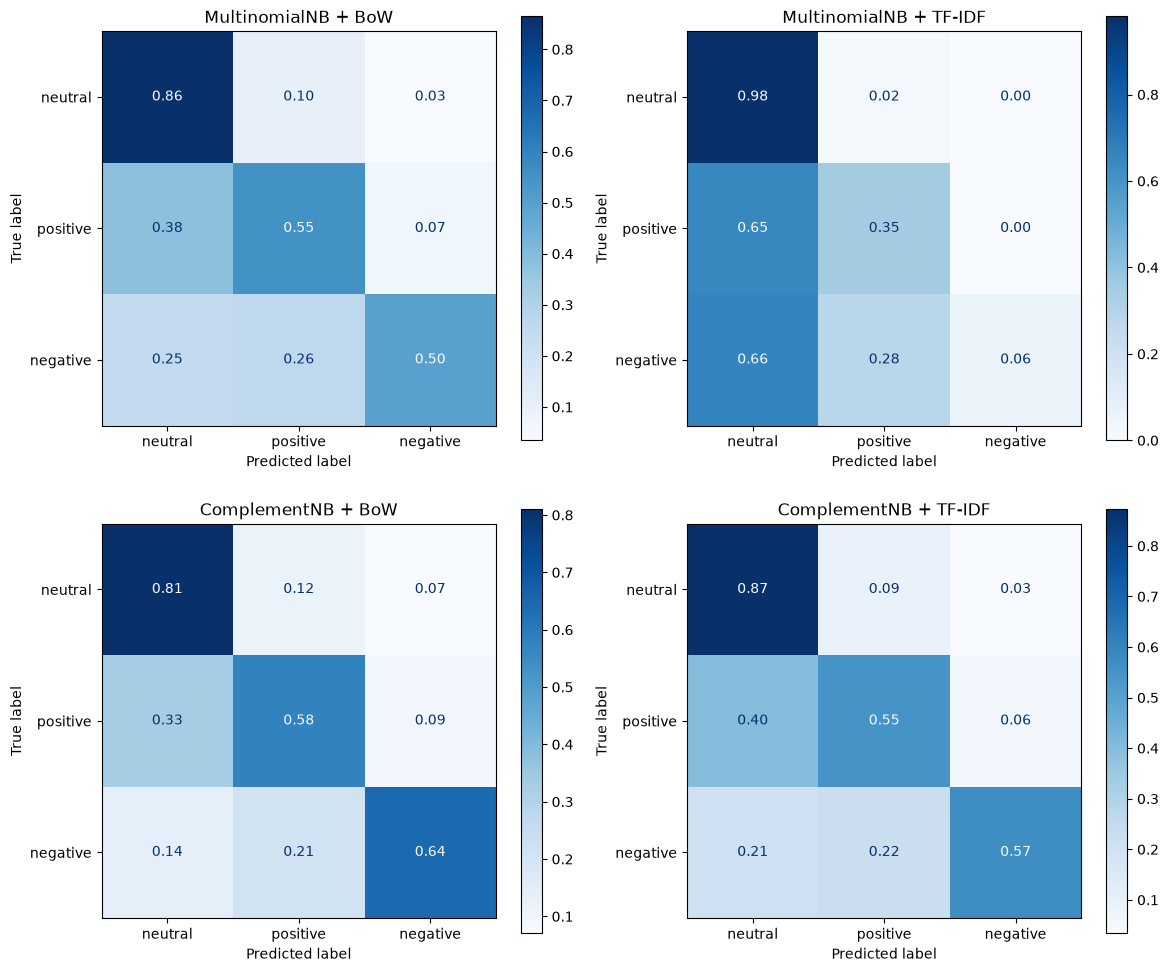

In [18]:
label_ids = [0, 1, 2]
label_names = ["neutral", "positive", "negative"]

plots = [
    ("MultinomialNB + BoW", pred_bog),
    ("MultinomialNB + TF-IDF", pred_tfidf),
    ("ComplementNB + BoW", y_pred_complement_bow),
    ("ComplementNB + TF-IDF", y_pred_complement_tfidf),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (title, y_pred) in zip(axes.ravel(), plots):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        labels=label_ids,
        display_labels=label_names,
        normalize="true",
        values_format=".2f",
        ax=ax,
        colorbar=True,
        cmap="Blues"
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

### Binary Naive Bayes, BoW

In [32]:
df_binary_train = df.drop(df[df["label"] == 0].index)
print(df_binary_train['label'].value_counts())

df_binary_test = pd.DataFrame({
    'text': X_test,
    'label': y_test
})
df_binary_test = df_binary_test.drop(df_binary_test[df_binary_test['label'] == 0].index)
print(df_binary_test['label'].value_counts())

label
1    1090
2     483
Name: count, dtype: int64
label
1    273
2    121
Name: count, dtype: int64


In [ ]:
model = Pipeline([
        ("vectorizer", CountVectorizer()),
        ("classifier", MultinomialNB())
    ])
model.fit(df_binary_train['text'], df_binary_train['label'])
y_binary_pred = model.predict(df_binary_test['text'])

print(f"Report:\n{classification_report(df_binary_test['label'], y_binary_pred)}")

Report:
              precision    recall  f1-score   support

           1       0.87      0.85      0.86       273
           2       0.68      0.71      0.69       121

    accuracy                           0.81       394
   macro avg       0.77      0.78      0.78       394
weighted avg       0.81      0.81      0.81       394

